In [ ]:
import pandas as pd

dataset = pd.read_csv('../CKD.csv')
dataset = pd.get_dummies(dataset, drop_first=True, dtype=int)
dataset

,age,bp,al,su,bgr,bu,sc,sod,pot,hrmo,...,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_yes,pe_yes,ane_yes,classification_yes
0,2.000000,76.459948,3.0,0.0,148.112676,57.482105,3.077356,137.528754,4.627244,12.518156,...,0,0,0,0,0,0,1,1,0,1
1,3.000000,76.459948,2.0,0.0,148.112676,22.000000,0.700000,137.528754,4.627244,10.700000,...,1,0,0,0,0,0,1,0,0,1
2,4.000000,76.459948,1.0,0.0,99.000000,23.000000,0.600000,138.000000,4.400000,12.000000,...,1,0,0,0,0,0,1,0,0,1
3,5.000000,76.459948,1.0,0.0,148.112676,16.000000,0.700000,138.000000,3.200000,8.100000,...,1,0,0,0,0,0,1,0,1,1
4,5.000000,50.000000,0.0,0.0,148.112676,25.000000,0.600000,137.528754,4.627244,11.800000,...,1,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,51.492308,70.000000,0.0,0.0,219.000000,36.000000,1.300000,139.000000,3.700000,12.500000,...,1,0,0,0,0,0,1,0,0,1
395,51.492308,70.000000,0.0,2.0,220.000000,68.000000,2.800000,137.528754,4.627244,8.700000,...,1,0,0,1,1,0,1,0,1,1
396,51.492308,70.000000,3.0,0.0,110.000000,115.000000,6.000000,134.000000,2.700000,9.100000,...,1,0,0,1,1,0,0,0,0,1
397,51.492308,90.000000,0.0,0.0,207.000000,80.000000,6.800000,142.000000,5.500000,8.500000,...,1,0,0,1,1,0,1,0,1,1


In [11]:
features = dataset.drop("classification_yes", axis=1)
label = dataset['classification_yes']

label.value_counts()

classification_yes
1    249
0    150
Name: count, dtype: int64

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(features, label, test_size=0.3, random_state=0)

In [5]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
x_test_scaled = sc.transform(X_test)

<function matplotlib.pyplot.show(close=None, block=None)>

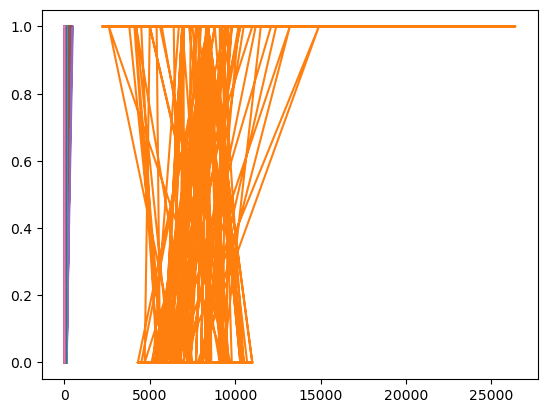

In [7]:
import matplotlib.pyplot as plt

plt.plot(features, label)
plt.show

In [18]:
def confusionMatrix(yTest, yPred):
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(yTest, yPred)
    return cm

In [19]:
# 1.Logistic Regression
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression(
    penalty="l2", C=1, class_weight="balanced", solver="liblinear", random_state=0
)
logistic.fit(X_train, y_train)
logistic_pred = logistic.predict(X_test)
cm = confusionMatrix(y_test, logistic_pred)
cm


array([[44,  1],
       [ 1, 74]])

In [29]:
from sklearn.metrics import classification_report
cr = classification_report(y_test, logistic_pred)
cr_dict = classification_report(y_test, logistic_pred, output_dict=True)
print(cr_dict['accuracy'])


0.9833333333333333
